In [26]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

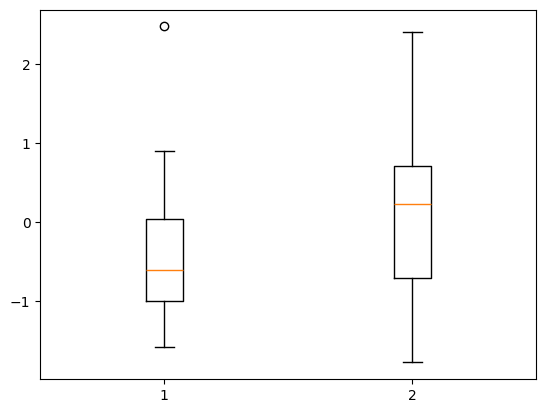

In [27]:
rng = np.random.default_rng()
n = 20
Y = rng.normal(size=(n, 2))
plt.boxplot([Y[:, 0], Y[:, 1]])
plt.show()

Set
$$
\bar{y} = \frac1{IJ}\sum_{i < I}\sum_{j < J}y_{ij}.
$$

For each $i < I$, set
$$
\bar{y}_i = \frac1J\sum_{j < J} y_{ij}.
$$

Using the fact that
$$
\sum_{j < J}(y_{ij} - \bar{y}_i) = 0
$$
for all $i$, we get
$$
\begin{aligned}
\sum_{i < I}\sum_{j < J}(y_{ij} - \bar{y})^2 
&= \sum_{i < I}\sum_{j < J}(y_{ij} - \bar{y}_i + \bar{y}_i - \bar{y})^2\\
&= \sum_{i < I}\sum_{j < J}\left\{(y_{ij} - \bar{y}_i)^2 + (\bar{y}_i - \bar{y})^2 + 2(y_{ij} - \bar{y}_i)(\bar{y}_i - \bar{y})\right\}\\
&= \sum_{i < I}\sum_{j < J}(y_{ij} - \bar{y}_i)^2 + J\sum_{i < I} (\bar{y}_i - \bar{y})^2
+ 2\sum_{i < I}(\bar{y}_i - \bar{y})\sum_{j < J}(y_{ij} - \bar{y}_i)\\
&= \sum_{i < I}\sum_{j < J}(y_{ij} - \bar{y}_i)^2 + J\sum_{i < I} (\bar{y}_i - \bar{y})^2.
\end{aligned}
$$

We set
$$
\begin{aligned}
\operatorname{SST} &= \sum_{i < I}\sum_{j < J}(y_{ij} - \bar{y})^2,\\
\operatorname{SSW} &= \sum_{i < I}\sum_{j < J}(y_{ij} - \bar{y}_i)^2,\\
\operatorname{SSB} &= J\sum_{i < I} (\bar{y}_i - \bar{y})^2,
\end{aligned}
$$
so that
$$
\operatorname{SST} = \operatorname{SSW} + \operatorname{SSB}.
$$

$$
V[x] = E[(x - E[x])^2] = E[x^2] + E[x]^2 - 2E[xE[x]] = E[x^2] - E[x]^2
$$

$$
E[x^2] = V[x] + E[x]^2 = \sigma^2 + \mu^2
$$
Suppose $x_i$, $i < I$, are independent with means $\mu_i$ and common variance $\sigma^2$. Then
$$
\begin{aligned}
E[(x_i - \bar{x})^2] &= E[x_i^2] + E[\bar{x}^2] -2E[x_i\bar{x}]\\
&= \left(1 - \frac2n\right)E[x_i^2] + E[\bar{x}^2]\\
&= \left(1 - \frac2n\right)(\sigma^2 + \mu^2) + \frac{\sigma^2}{n} + \bar{\mu}^2
\end{aligned}
$$

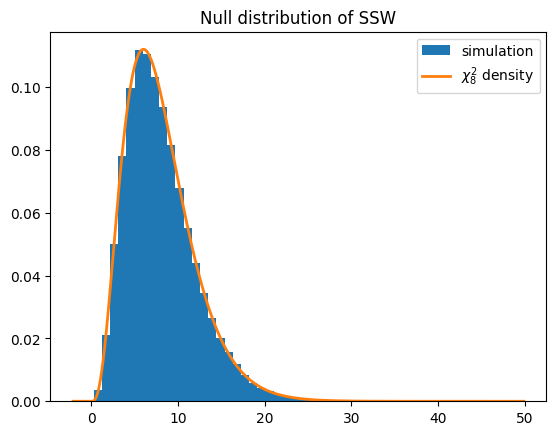

In [28]:
rng = np.random.default_rng()
I = 4
J = 3

r = 100000
SSW = np.zeros(r)
SSB = np.zeros(r)

for i in range(r):
    Y = rng.normal(size=(J, I))
    SSW[i] = np.sum((Y - Y.mean(axis=0, keepdims=True)) ** 2)
    SSB[i] = J * np.sum((Y.mean(axis=0) - Y.mean()) ** 2)

plt.hist(SSW, bins=50, density=True, label="simulation")
grid = np.linspace(*plt.xlim(), 1000)
df = I * (J - 1)
plt.plot(grid, stats.chi2.pdf(grid, df=df), lw=2, label=f"$\\chi^2_{{ {df} }}$ density")
plt.legend()
plt.title("Null distribution of SSW")
plt.show()

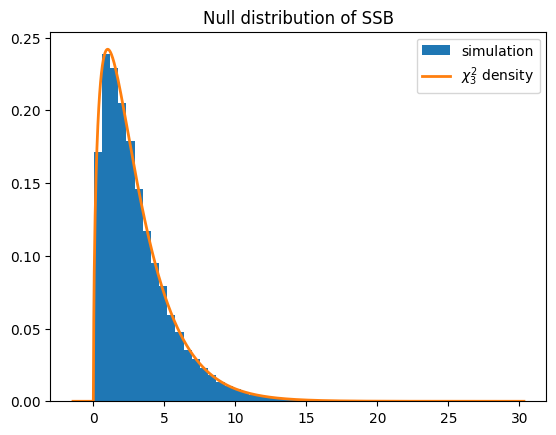

In [29]:
plt.hist(SSB, bins=50, density=True, label="simulation")
grid = np.linspace(*plt.xlim(), 1000)
df = I - 1
plt.plot(grid, stats.chi2.pdf(grid, df=df), lw=2, label=f"$\\chi^2_{{ {df} }}$ density")
plt.legend()
plt.title("Null distribution of SSB")
plt.show()

In [30]:
n = 10
rng = np.random.default_rng()
x = rng.normal(size=n)
y = rng.normal(size=n)
tstatistic, tpvalue = stats.ttest_ind(x, y)
print(f"{tstatistic=:.4f}, {tpvalue=:.4f}")

fstatistic, fpvalue = stats.f_oneway(x, y)
print(f"{fstatistic=:.4f}, {fpvalue=:.4f}")

assert np.isclose(fstatistic, tstatistic**2)
assert np.isclose(fpvalue, tpvalue)

tstatistic=-1.0878, tpvalue=0.2910
fstatistic=1.1834, fpvalue=0.2910


In [31]:
rng = np.random.default_rng()
J = 10

Y = rng.normal(size=(2, J))
tstatistic, tpvalue = stats.ttest_ind(Y[0], Y[1])

SSW = np.sum((Y - Y.mean(axis=1, keepdims=True)) ** 2)
dfW = 2 * (J - 1)
SSB = J * np.sum((Y.mean(axis=1) - Y.mean()) ** 2)

fstatistic, fpvalue = stats.f_oneway(*Y)
assert np.isclose(fstatistic, SSB / (SSW / dfW))

assert np.isclose(tpvalue, fpvalue)
assert np.isclose(tstatistic**2, fstatistic)

In [32]:
rng = np.random.default_rng()
I = 3
J = 10

Y = rng.normal(size=(I, J))

SSW = np.sum((Y - Y.mean(axis=1, keepdims=True)) ** 2)
dfW = I * (J - 1)
SSB = J * np.sum((Y.mean(axis=1) - Y.mean()) ** 2)
dfB = I - 1

fstatistic, fpvalue = stats.f_oneway(*Y)
assert np.isclose(fstatistic, (SSB / dfB) / (SSW / dfW))

In [33]:
# cement bond strenght data
# Montgomery, pp. 26, 39
x = [16.85, 16.40, 17.21, 16.35, 16.52, 17.04, 16.96, 17.15, 16.59, 16.57]
y = [16.62, 16.75, 17.37, 17.12, 16.98, 16.87, 17.34, 17.02, 17.08, 17.27]
stats.ttest_ind(x, y)

TtestResult(statistic=np.float64(-2.1868757949582633), pvalue=np.float64(0.0421967159248899), df=np.float64(18.0))